# Main Palette Attention Model

notebook for complete model orchestration

In [30]:
# Cell 1 — Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image

In [31]:
# Cell 2 — Reload df and vocabs
path = '/kaggle/input/models/manjushwarkhairkar/vocabs-and-category-configes/other/default/3/vocab_and_categories'
VOCAB_DIR = path
df = pd.read_csv(os.path.join(VOCAB_DIR, 'fashion_with_indices.csv'))
df = df.dropna(subset=['proc_img_path', 'proc_sketch_path']).reset_index(drop=True)
print(f"Loaded {len(df)} rows")

with open(os.path.join(VOCAB_DIR, 'colour_vocab.json'))   as f:
    colour_vocab   = json.load(f)
with open(os.path.join(VOCAB_DIR, 'category_vocab.json')) as f:
    category_vocab = json.load(f)

print(f"Colour vocab size  : {len(colour_vocab)}")
print(f"Category vocab size: {len(category_vocab)}")

Loaded 14311 rows
Colour vocab size  : 52
Category vocab size: 27


In [32]:
# Cell 3 — Rebuild dataset + dataloader
img_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])
sketch_transform = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=1),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

class MyntraSketchDataset(Dataset):
    def __init__(self, dataframe, img_tfm=None, sketch_tfm=None):
        self.df         = dataframe.reset_index(drop=True)
        self.img_tfm    = img_tfm
        self.sketch_tfm = sketch_tfm
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img    = Image.open(row['proc_img_path']).convert('RGB')
        sketch = Image.open(row['proc_sketch_path']).convert('RGB')
        if self.img_tfm:    img    = self.img_tfm(img)
        if self.sketch_tfm: sketch = self.sketch_tfm(sketch)
        return {
            'sketch'      : sketch,
            'image'       : img,
            'name'        : row['name'],
            'colour'      : row['colour'],
            'colour_idx'  : torch.tensor(int(row['colour_idx']),   dtype=torch.long),
            'category_idx': torch.tensor(int(row['category_idx']), dtype=torch.long),
            'idx'         : idx
        }

full_dataset = MyntraSketchDataset(df, img_tfm=img_transform, sketch_tfm=sketch_transform)
total   = len(full_dataset)
n_train = int(0.8 * total)
n_val   = int(0.1 * total)
n_test  = total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

PIN          = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=PIN)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=PIN)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Train batches: {len(train_loader)}")

Train: 11448 | Val: 1431 | Test: 1432
Train batches: 358


In [33]:
# Cell 4 — Rebuild all previous modules
class SketchEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone      = nn.Sequential(*list(resnet.children())[:-2])
        self.input_adapter = nn.Conv2d(1, 3, kernel_size=1, bias=False)
        for param in self.backbone.parameters():
            param.requires_grad = False
    def forward(self, sketch):
        return self.backbone(self.input_adapter(sketch))  # [B, 512, 7, 7]

class StyleEmbedding(nn.Module):
    def __init__(self, colour_vocab_size, category_vocab_size, embed_dim=64):
        super().__init__()
        self.colour_emb   = nn.Embedding(colour_vocab_size,   embed_dim, padding_idx=0)
        self.category_emb = nn.Embedding(category_vocab_size, embed_dim, padding_idx=0)
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
    def forward(self, colour_idx, category_idx):
        c = self.colour_emb(colour_idx)
        s = self.category_emb(category_idx)
        return self.fusion(torch.cat([c, s], dim=-1))  # [B, 128]

class LSTMCore(nn.Module):
    def __init__(self, encoder_dim=512, style_dim=128, hidden_size=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.hidden_size  = hidden_size
        self.num_layers   = num_layers
        self.encoder_proj = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(encoder_dim, hidden_size), nn.ReLU()
        )
        self.style_proj  = nn.Sequential(nn.Linear(style_dim, hidden_size), nn.ReLU())
        self.input_proj  = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size), nn.ReLU(), nn.Dropout(dropout)
        )
        self.gru = nn.GRU(
            input_size=hidden_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.layer_norm = nn.LayerNorm(hidden_size)
    def forward(self, encoder_features, style_vector, hidden=None):
        enc_ctx = self.encoder_proj(encoder_features)
        sty_ctx = self.style_proj(style_vector)
        fused   = self.input_proj(torch.cat([enc_ctx, sty_ctx], dim=-1)).unsqueeze(1)
        out, hidden = self.gru(fused, hidden)
        return self.layer_norm(out.squeeze(1)), hidden  # [B, 256]

class ConditionalSpatialAttention(nn.Module):
    def __init__(self, encoder_dim=512, hidden_size=256, style_dim=128, attn_dim=256):
        super().__init__()
        self.condition_proj = nn.Sequential(
            nn.Linear(hidden_size + style_dim, encoder_dim), nn.ReLU()
        )
        self.attn_conv = nn.Sequential(
            nn.Conv2d(encoder_dim * 2, attn_dim, kernel_size=1), nn.ReLU(),
            nn.Conv2d(attn_dim, 1, kernel_size=1)
        )
    def forward(self, feature_map, hidden_state, style_vector, sketch=None):
        B, C, H, W = feature_map.shape
        condition  = self.condition_proj(
            torch.cat([hidden_state, style_vector], dim=-1)
        ).unsqueeze(-1).unsqueeze(-1).expand(B, C, H, W)
        logits = self.attn_conv(torch.cat([feature_map, condition], dim=1))
        if sketch is not None:
            sketch_01  = (sketch * 0.5) + 0.5
            silhouette = (sketch_01 > 0.1).float()
            mask       = F.interpolate(silhouette, size=(H, W), mode='nearest')
            logits     = logits.masked_fill(mask == 0, float('-inf'))
        attn_weights = F.softmax(logits.view(B, -1), dim=-1).view(B, 1, H, W)
        context      = (feature_map * attn_weights).sum(dim=[-2, -1])
        return context, attn_weights  # [B, 512], [B, 1, 7, 7]

encoder        = SketchEncoder()
style_embedder = StyleEmbedding(len(colour_vocab), len(category_vocab), embed_dim=64)
lstm_core      = LSTMCore(encoder_dim=512, style_dim=128, hidden_size=256, num_layers=2)
attention      = ConditionalSpatialAttention(encoder_dim=512, hidden_size=256, style_dim=128)

encoder.eval()
style_embedder.eval()
lstm_core.eval()
attention.eval()
print("All previous modules initialized!")

All previous modules initialized!


In [34]:
# Cell 5 — SpatialAttentionDecoder class
class SpatialAttentionDecoder(nn.Module):

    def __init__(self,
                 context_dim  = 512,   # from attention
                 lstm_dim     = 256,   # from lstm core
                 style_dim    = 128,   # from style embedding
                 vocab_size   = 50,    # for token prediction head
                 dropout      = 0.1):
        super().__init__()

        fused_dim = context_dim + lstm_dim + style_dim  # 512+256+128 = 896

        # ── fusion layer ──
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ── synthesis head: 512 → [3, 224, 224] ──
        # reshape [B, 512] → [B, 512, 1, 1] then upsample
        self.synthesis_head = nn.Sequential(

            # 1×1 → 7×7
            nn.ConvTranspose2d(512, 256, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # 7×7 → 14×14
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 14×14 → 28×28
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 28×28 → 56×56
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # 56×56 → 112×112
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            # 112×112 → 224×224
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()   # output in [-1, 1] matching ImageNet normalization range
        )

        # ── token prediction head ──
        self.token_head = nn.Sequential(
            nn.Linear(lstm_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, vocab_size)   # logits over vocab
        )

    def forward(self, context, lstm_out, style_vector, sketch=None):
        # context     : [B, 512]
        # lstm_out    : [B, 256]
        # style_vector: [B, 128]
        # sketch      : [B, 1, 224, 224] optional for structural masking

        # ── fuse all inputs ──
        fused = torch.cat([context, lstm_out, style_vector], dim=-1)  # [B, 896]
        fused = self.fusion(fused)                                     # [B, 512]

        # ── synthesis head ──
        # reshape to spatial: [B, 512] → [B, 512, 1, 1]
        spatial = fused.unsqueeze(-1).unsqueeze(-1)                    # [B, 512, 1, 1]
        outfit  = self.synthesis_head(spatial)                         # [B, 3, 224, 224]

        # ── structural mask — anti-bleeding at output level ──
        if sketch is not None:
            sketch_01  = (sketch * 0.5) + 0.5                         # [-1,1] → [0,1]
            silhouette = (sketch_01 > 0.1).float()                     # [B, 1, 224, 224]
            outfit     = outfit * silhouette                           # zero outside garment

        # ── token prediction head ──
        token_logits = self.token_head(lstm_out)                       # [B, vocab_size]

        return outfit, token_logits
        # outfit       → [B, 3, 224, 224]  reconstructed outfit image
        # token_logits → [B, vocab_size]   next token prediction

In [35]:
# Cell 6 — Loss functions
class DecoderLoss(nn.Module):

    def __init__(self, token_weight=0.1):
        super().__init__()
        self.token_weight = token_weight
        self.mse          = nn.MSELoss()
        self.ce           = nn.CrossEntropyLoss()

        # VGG16 for perceptual loss — frozen
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        self.vgg_features = nn.Sequential(*list(vgg.features)[:16]).eval()
        for param in self.vgg_features.parameters():
            param.requires_grad = False

    def perceptual_loss(self, generated, target):
        gen_feats = self.vgg_features(generated)
        tgt_feats = self.vgg_features(target)
        return self.mse(gen_feats, tgt_feats)

    def forward(self, outfit, token_logits, target_image, target_token):
        # reconstruction loss = MSE + perceptual
        mse_loss        = self.mse(outfit, target_image)
        perceptual_loss = self.perceptual_loss(outfit, target_image)
        recon_loss      = mse_loss + 0.1 * perceptual_loss

        # token prediction loss
        token_loss = self.ce(token_logits, target_token)

        # combined
        total_loss = recon_loss + self.token_weight * token_loss

        return total_loss, {
            'total'      : total_loss.item(),
            'mse'        : mse_loss.item(),
            'perceptual' : perceptual_loss.item(),
            'token'      : token_loss.item()
        }

In [36]:
# Cell 7 — Instantiate and inspect
decoder      = SpatialAttentionDecoder(
    context_dim = 512,
    lstm_dim    = 256,
    style_dim   = 128,
    vocab_size  = len(category_vocab),
    dropout     = 0.1
)
criterion    = DecoderLoss(token_weight=0.1)

total     = sum(p.numel() for p in decoder.parameters())
trainable = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f"Decoder total params    : {total:,}")
print(f"Decoder trainable params: {trainable:,}")
print(f"\nLoss function ready: MSE + Perceptual + Token CE")

Decoder total params    : 7,616,750
Decoder trainable params: 7,616,750

Loss function ready: MSE + Perceptual + Token CE


In [37]:
# Cell 8 — Sanity check full forward pass
batch        = next(iter(train_loader))
sketches     = batch['sketch']            # [32, 1, 224, 224]
images       = batch['image']             # [32, 3, 224, 224]
colour_idx   = batch['colour_idx']        # [32]
category_idx = batch['category_idx']      # [32]

with torch.no_grad():
    # full pipeline
    features              = encoder(sketches)
    style_vec             = style_embedder(colour_idx, category_idx)
    lstm_out, _           = lstm_core(features, style_vec)
    context, attn_weights = attention(features, lstm_out, style_vec, sketches)
    outfit, token_logits  = decoder(context, lstm_out, style_vec, sketches)

print(f"Context shape      : {context.shape}")
print(f"LSTM out shape     : {lstm_out.shape}")
print(f"Outfit shape       : {outfit.shape}")
print(f"Token logits shape : {token_logits.shape}")
print(f"\nExpected outfit    : torch.Size([32, 3, 224, 224])")
print(f"Outfit match       : {outfit.shape == torch.Size([32, 3, 224, 224])}")

# compute loss
total_loss, loss_dict = criterion(outfit, token_logits, images, category_idx)
print(f"\nTotal loss   : {loss_dict['total']:.4f}")
print(f"MSE loss     : {loss_dict['mse']:.4f}")
print(f"Perceptual   : {loss_dict['perceptual']:.4f}")
print(f"Token loss   : {loss_dict['token']:.4f}")

Context shape      : torch.Size([32, 512])
LSTM out shape     : torch.Size([32, 256])
Outfit shape       : torch.Size([32, 3, 224, 224])
Token logits shape : torch.Size([32, 27])

Expected outfit    : torch.Size([32, 3, 224, 224])
Outfit match       : True

Total loss   : 4.5016
MSE loss     : 3.1712
Perceptual   : 9.8916
Token loss   : 3.4130


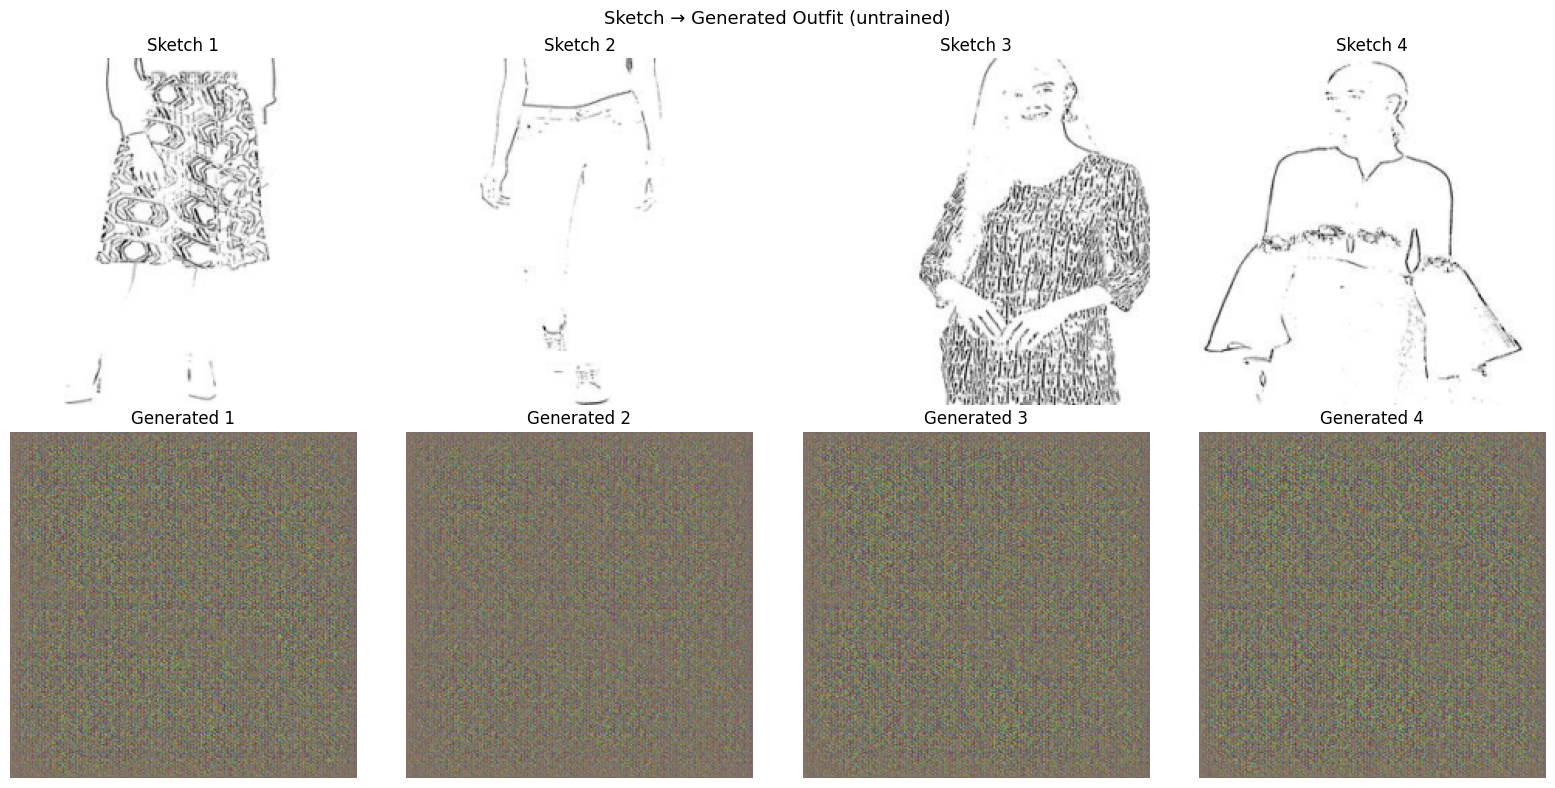

Decoder output saved!


In [38]:
# Cell 9 — Visualize first reconstruction
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    # input sketch
    sketch_np = sketches[i].squeeze().numpy()
    axes[0][i].imshow(sketch_np, cmap='gray')
    axes[0][i].set_title(f'Sketch {i+1}')
    axes[0][i].axis('off')

    # generated outfit
    outfit_np = denormalize(outfit[i].detach()).permute(1, 2, 0).numpy()
    axes[1][i].imshow(outfit_np)
    axes[1][i].set_title(f'Generated {i+1}')
    axes[1][i].axis('off')

plt.suptitle('Sketch → Generated Outfit (untrained)', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/decoder_output.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decoder output saved!")

In [39]:
# Cell 10 — Save
torch.save(decoder.state_dict(),   '/kaggle/working/decoder.pt')
torch.save(criterion.state_dict(), '/kaggle/working/criterion.pt')
print("Saved: decoder.pt")
print("Saved: criterion.pt")

Saved: decoder.pt
Saved: criterion.pt
